## **Algorithm : Linear SVM :**

### **Project : Breast Tumor Classification** 

#### **Problem Statement : Classify breast tumors as malignant or benign using medical measurements of cell nuclei.**

In [1]:
# Step No 1 : Import Required Libraries

# Import Numerical library
import numpy as np 

# import pandas library 
import pandas as pd 

# Import Plotting library 
import matplotlib.pyplot as plt 

# Import seaborn library 
import seaborn as sns 

# Import train test split 
from sklearn.model_selection import train_test_split

# Import Label Encoder 
from sklearn.preprocessing import LabelEncoder

# Import Standard Scaler 
from sklearn.preprocessing import StandardScaler

# import Support Vector Classifier 
from sklearn.svm import SVC

# Import Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

In [2]:
# Step No 2 : Load Dataset 
df = pd.read_csv("Breast_Cancer_Classification_Dataset.csv")

In [3]:
# Step No 3 : Data Understanding 

# Display first 5 rows 
print("\nFirst 5 Rows : ")
print(df.head())

# Display dataset shape 
print("\nDataset Shape : ")
print(df.shape)

# Display column names 
print("\nColumn Names : ")
print(df.columns.tolist())

# Display dataset information
print("\nDataset Information : ")
df.info()

# Dsplay Statistical Summary 
print("\nStatistical Summary : ")
print(df.describe())


First 5 Rows : 
   PatientID  mean radius  mean texture  mean perimeter  mean area  \
0          1        17.99         10.38          122.80     1001.0   
1          2        20.57         17.77          132.90     1326.0   
2          3        19.69         21.25          130.00     1203.0   
3          4        11.42         20.38           77.58      386.1   
4          5        20.29         14.34          135.10     1297.0   

   mean smoothness  mean compactness  mean concavity  mean concave points  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   mean symmetry  ...  worst texture  worst perimeter  worst area  \
0         0.2419  ...         

In [4]:
# Step No 4 : Data Cleaning 

print("\nDuplicate Rows : ")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates : ")
print(df.shape)

print("\nMissing Values After Cleaning : ")
print(df.isnull().sum())


Duplicate Rows : 
0

Dataset Shape After Removing Duplicates : 
(569, 32)

Missing Values After Cleaning : 
PatientID                  0
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimensi

In [5]:
# Step No 5 : Encode Target Variable 

# Create Label Encoder Object 
encoder = LabelEncoder()

# Convert Diagnosis into numerical values 
# Benign and Malignant will become 0 and 1 
df["Diagnosis"] = encoder.fit_transform(df["Diagnosis"])

# Display encoded target distribution 
print("\nEncoded Diagnosis Distribution : ")
print(df["Diagnosis"].value_counts())

# Display encoding mapping 
print("\nDiagnosis Encoding : ")
for label , value in zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
):
    
    print(label , "=" , value)


Encoded Diagnosis Distribution : 
Diagnosis
0    357
1    212
Name: count, dtype: int64

Diagnosis Encoding : 
Benign = 0
Malignant = 1


In [6]:
# Step No 6 : Define Features and Target 

# Features
# PatientID is removed because it is only an identifier.

X = df.drop(
    columns=[
        "PatientID",
        "Diagnosis"
    ]
)

# Target
y = df["Diagnosis"]

# Display feature shape
print("\nFeature Shape:")
print(X.shape)

# Display target shape
print("\nTarget Shape:")
print(y.shape)

# Display feature names
print("\nFeature Names:")

for i, feature in enumerate(
    X.columns,
    start=1
):
    print(i, ":", feature)



Feature Shape:
(569, 30)

Target Shape:
(569,)

Feature Names:
1 : mean radius
2 : mean texture
3 : mean perimeter
4 : mean area
5 : mean smoothness
6 : mean compactness
7 : mean concavity
8 : mean concave points
9 : mean symmetry
10 : mean fractal dimension
11 : radius error
12 : texture error
13 : perimeter error
14 : area error
15 : smoothness error
16 : compactness error
17 : concavity error
18 : concave points error
19 : symmetry error
20 : fractal dimension error
21 : worst radius
22 : worst texture
23 : worst perimeter
24 : worst area
25 : worst smoothness
26 : worst compactness
27 : worst concavity
28 : worst concave points
29 : worst symmetry
30 : worst fractal dimension


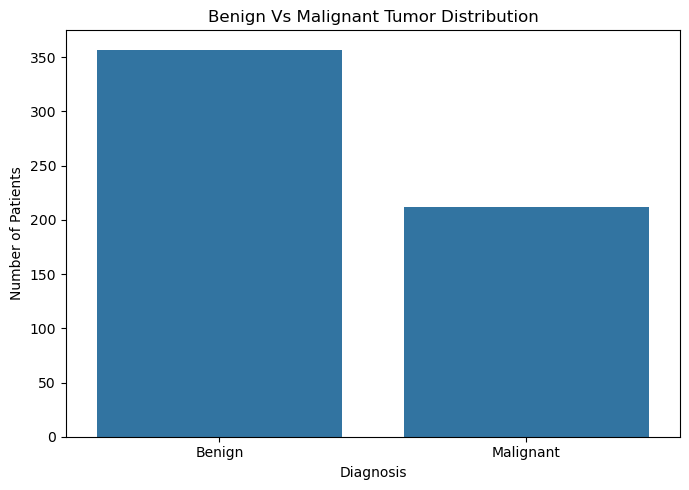

In [7]:
# STEP 7 : Target Variable Visualisation
# Create Count Plot
plt.figure(figsize=(7, 5))

sns.countplot(
    x="Diagnosis",
    data=df
)

# Set Plot title
plt.title(
    "Benign Vs Malignant Tumor Distribution"
)

# Set x-axis label
plt.xlabel(
    "Diagnosis"
)

# Set y-axis label
plt.ylabel(
    "Number of Patients"
)

# Display original class names
plt.xticks(
    ticks=range(len(encoder.classes_)),
    labels=encoder.classes_
)

plt.tight_layout()

# Display Plot
plt.show()

In [8]:
# Step No 8 : Train Test Split 
# Split dataset into training and testing data 
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size= 0.20,
    random_state=42,
    stratify=y
)

# Display training and testing shapes 
print("\nTraining Feature Shape : ")
print(X_train.shape)

print("\nTesting Feature Shape : ")
print(X_test.shape)

print("\nTraining Target Shape : ")
print(y_train.shape)

print("\nTesting Target Shape : ")
print(y_test.shape)


Training Feature Shape : 
(455, 30)

Testing Feature Shape : 
(114, 30)

Training Target Shape : 
(455,)

Testing Target Shape : 
(114,)


In [9]:
# Step No 9 : Feature Scaling 

# Create StandardScaler
scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(
    X_train
)

# Transform test data
X_test_scaled = scaler.transform(
    X_test
)

print("\nFeature Scaling Completed.")


Feature Scaling Completed.


In [10]:
# Step No 10 : Create Linear SVM Model 
# Create Linear SVM Classifier 
model = SVC(
    kernel="linear",
    C=1.0,
    probability=True,
    random_state=42
)

# Display Model 
print("\nModel : ")
print(model)


Model : 
SVC(kernel='linear', probability=True, random_state=42)


In [11]:
# Step No 11 : Train Linear SVM Model 
# Train the model using scaled training data 
model.fit(
    X_train_scaled , 
    y_train
)

# Display training completion
print("\nLinear SVM Model Training Completed .")


Linear SVM Model Training Completed .


In [12]:
# Step No : 12 Make Prediction
# Predict class
y_pred = model.predict(
    X_test_scaled
)

# Predict probability
y_probability = model.predict_proba(
    X_test_scaled
)

# Display Predicted Values
print("\nPredicted Values : ")
print(y_pred)


Predicted Values : 
[0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0
 0 1 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0
 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0
 0 0 1]


In [13]:
# Step No 13 : Model Evaluation 
# Calculate Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

# Calculate Precision
precision = precision_score(
    y_test,
    y_pred
)

# Calculate Recall
recall = recall_score(
    y_test,
    y_pred
)

# Calculate F1 Score
f1 = f1_score(
    y_test,
    y_pred
)

# Calculate ROC-AUC
roc_auc = roc_auc_score(
    y_test,
    y_probability[:, 1]
)



# Confusion Matrix 
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix : ")
print(cm)

# Display Model Evaluation
print("\n================================")
print("       MODEL EVALUATION")
print("================================")

print(
    "Accuracy :",
    round(accuracy * 100, 2),
    "%"
)

print(
    "Precision :",
    round(precision * 100, 2),
    "%"
)

print(
    "Recall :",
    round(recall * 100, 2),
    "%"
)

print(
    "F1 Score :",
    round(f1 * 100, 2),
    "%"
)

print(
    "ROC-AUC :",
    round(roc_auc, 4)
)

print("================================")


Confusion Matrix : 
[[72  0]
 [ 4 38]]

       MODEL EVALUATION
Accuracy : 96.49 %
Precision : 100.0 %
Recall : 90.48 %
F1 Score : 95.0 %
ROC-AUC : 0.9914


In [14]:
# Step No 14 : Classification Report 
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)


Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [15]:
# Step No 15 : Calculate confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[72  0]
 [ 4 38]]


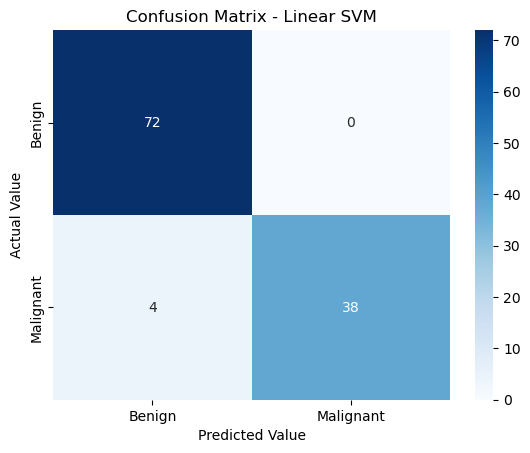

In [16]:
# Step No 16 : Confusion Matrix Visualization 
# Create Heatmap 
sns.heatmap(
    cm,
    annot=True,
    fmt = "d",
    cmap = "Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

# Set Plot Title 
plt.title("Confusion Matrix - Linear SVM")

# Set x-axis label 
plt.xlabel("Predicted Value")

# Set y-axis label 
plt.ylabel("Actual Value")

# Display Plot 
plt.show()

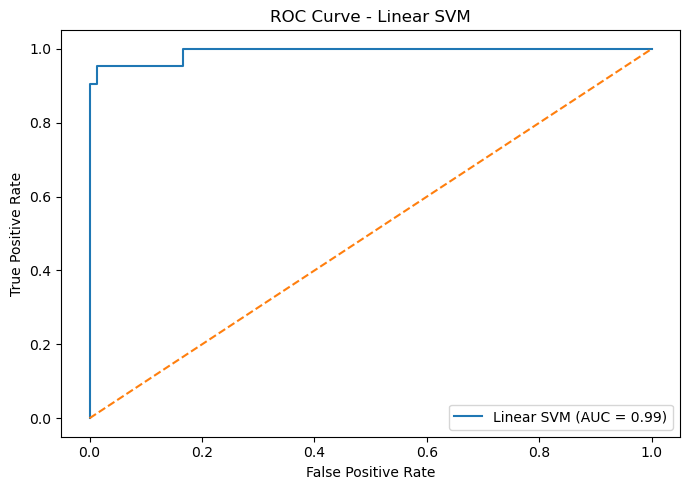

In [17]:
# Step No 17 : ROC CURVE

# Calculate False Positive Rate
# and True Positive Rate

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability[:, 1]
)


plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Linear SVM (AUC = {roc_auc:.2f})"
)

# Random classifier line

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    "ROC Curve - Linear SVM"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.tight_layout()

plt.show()


In [18]:
# Step No 18 : Final Model Performance 
# Display final model accuracy 
print("\n==========================================")
print("             FINAL MODEL SUMMARY")
print("==========================================")

print(
    "Algorithm        : Linear SVM"
)

print(
    "Kernel           : Linear"
)

print(
    "C Parameter      : 1.0"
)

print(
    "Total Features   :",
    len(X.columns)
)

print(
    "Training Samples :",
    len(X_train)
)

print(
    "Testing Samples  :",
    len(X_test)
)

print(
    "Accuracy         :",
    round(accuracy * 100, 2),
    "%"
)

print(
    "Precision        :",
    round(precision * 100, 2),
    "%"
)

print(
    "Recall           :",
    round(recall * 100, 2),
    "%"
)

print(
    "F1 Score         :",
    round(f1 * 100, 2),
    "%"
)

print(
    "ROC-AUC          :",
    round(roc_auc, 4)
)

print("==========================================")


             FINAL MODEL SUMMARY
Algorithm        : Linear SVM
Kernel           : Linear
C Parameter      : 1.0
Total Features   : 30
Training Samples : 455
Testing Samples  : 114
Accuracy         : 96.49 %
Precision        : 100.0 %
Recall           : 90.48 %
F1 Score         : 95.0 %
ROC-AUC          : 0.9914


In [19]:
# Step No 19 : New Patient Prediction
choice = input(
    "\nDo you want to predict a new patient? (yes/no): "
)


if choice.lower() == "yes":

    print("\n==========================================")
    print("       NEW PATIENT PREDICTION")
    print("==========================================")

    print(
        "\nEnter values for the following medical features:"
    )
    # Empty list
    user_values = []

    # Take input for every feature
    for feature in X.columns:

        while True:

            try:

                value = float(
                    input(
                        f"Enter {feature}: "
                    )
                )

                user_values.append(
                    value
                )
                break

            except ValueError:

                print(
                    "Please enter a valid numeric value."
                )


    # Create DataFrame
    user_data = pd.DataFrame(
        [user_values],
        columns=X.columns
    )
    # Scale new patient data
    user_data_scaled = scaler.transform(
        user_data
    )


    # Predict class
    user_prediction = model.predict(
        user_data_scaled
    )


    # Predict probability
    user_probability = model.predict_proba(
        user_data_scaled
    )
    
    # Convert numerical prediction
    # back to original class
    predicted_class = encoder.inverse_transform(
        user_prediction
    )[0]


    # Get probability of predicted class
    prediction_probability = (
        user_probability[
            0,
            user_prediction[0]
        ] * 100
    )
    
    # DISPLAY PREDICTION
    # ========================================================

    print("\n==========================================")
    print("             MODEL PREDICTION")
    print("==========================================")

    print(
        "Predicted Diagnosis :",
        predicted_class
    )

    print(
        "Prediction Probability :",
        round(
            prediction_probability,
            2
        ),
        "%"
    )
    
    print("==========================================")

    print(
        "\nNote: This is an ML model prediction "
        "and not a medical diagnosis."
    )


else:

    print(
        "\nPrediction cancelled."
    )


       NEW PATIENT PREDICTION

Enter values for the following medical features:

             MODEL PREDICTION
Predicted Diagnosis : Malignant
Prediction Probability : 100.0 %

Note: This is an ML model prediction and not a medical diagnosis.
